In [10]:
!pip install statsmodels
!pip install seaborn

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

file_path = 'CPS_clean_final.csv'
df = pd.read_csv(file_path, low_memory=False)

/tmp/ipykernel_3714/754080105.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='exp', y='ln_wage', ci=None)


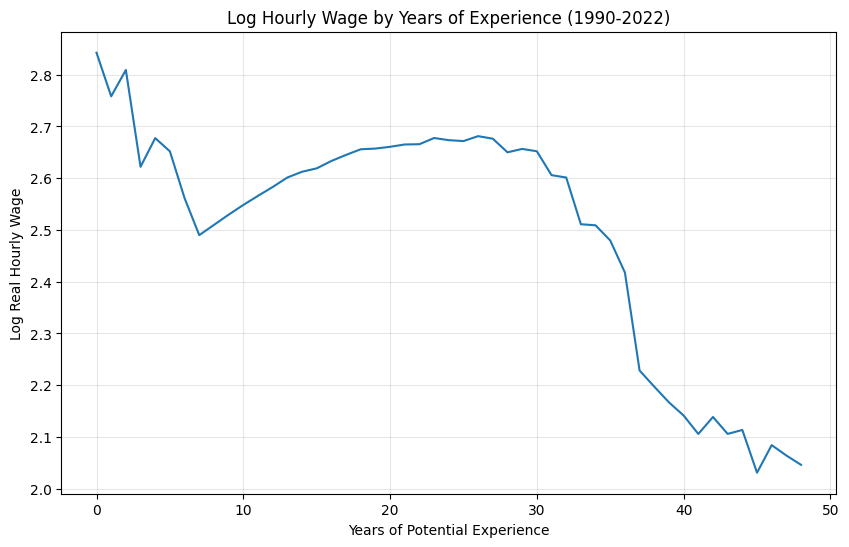

In [12]:
# Wages rise with experience
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='exp', y='ln_wage', ci=None)
plt.title('Log Hourly Wage by Years of Experience (1990-2022)')
plt.xlabel('Years of Potential Experience')
plt.ylabel('Log Real Hourly Wage')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_3714/4126168558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='educ_yrs', y='ln_wage', palette='viridis')


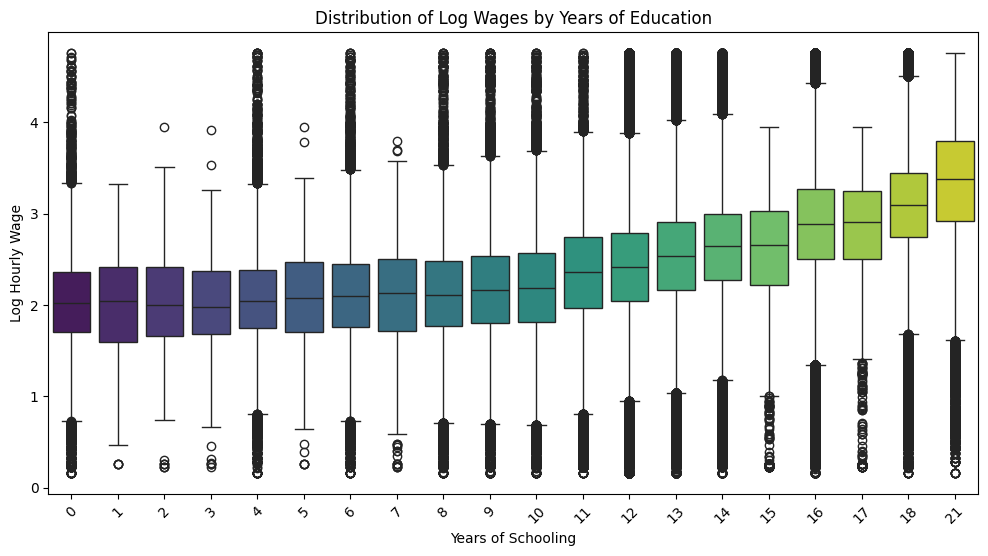

In [13]:
# Boxplot of wages by education level
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='educ_yrs', y='ln_wage', palette='viridis')
plt.title('Distribution of Log Wages by Years of Education')
plt.xlabel('Years of Schooling')
plt.ylabel('Log Hourly Wage')
plt.xticks(rotation=45)
plt.show()

In [14]:
X = df[['educ_yrs', 'exp', 'exp2']]
X = sm.add_constant(X)
y = df['ln_wage']
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                 1.477e+05
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:06:34   Log-Likelihood:            -1.8149e+06
No. Observations:             1945447   AIC:                         3.630e+06
Df Residuals:                 1945443   BIC:                         3.630e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9689      0.003    325.472      0.0

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                 1.158e+05
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:06:48   Log-Likelihood:            -1.7609e+06
No. Observations:             1945447   AIC:                         3.522e+06
Df Residuals:                 1945441   BIC:                         3.522e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

100%|██████████| 33/33 [00:01<00:00, 20.78it/s]


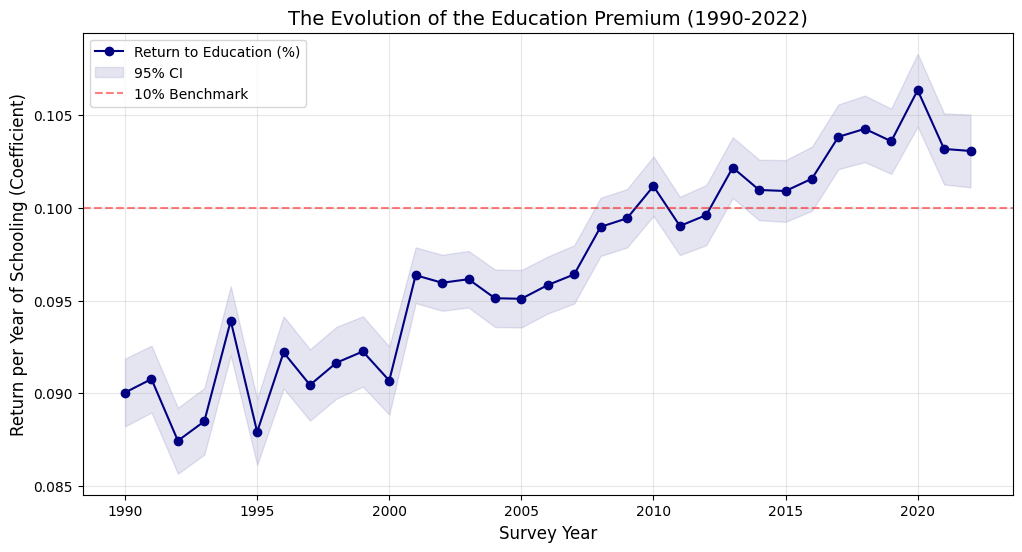

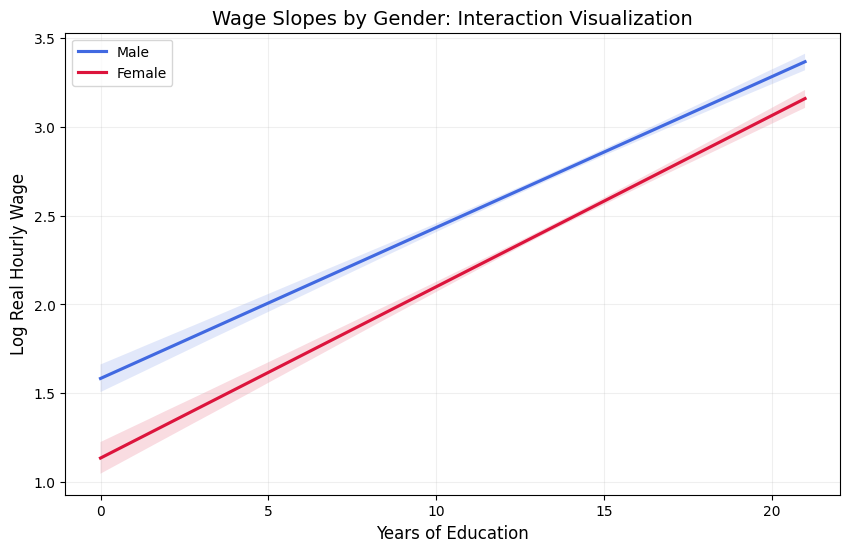

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm

df = pd.read_csv(file_path, low_memory=False)

df['exp_centered'] = df['exp'] - df['exp'].mean()
df['exp2_centered'] = df['exp_centered']**2

interaction_model = smf.ols(
    formula="ln_wage ~ educ_yrs * C(sex) + exp_centered + exp2_centered",
    data=df
).fit()

print(interaction_model.summary())

years = sorted(df['year'].unique())
edu_coefficients = []
conf_intervals = []

for yr in tqdm(years):
    yearly_res = smf.ols(
        formula="ln_wage ~ educ_yrs + exp_centered + exp2_centered",
        data=df[df['year'] == yr]
    ).fit()

    edu_coefficients.append(yearly_res.params['educ_yrs'])
    conf_intervals.append(yearly_res.conf_int().loc['educ_yrs'].tolist())

time_trends = pd.DataFrame({
    'year': years,
    'beta_educ': edu_coefficients,
    'lower': [i[0] for i in conf_intervals],
    'upper': [i[1] for i in conf_intervals]
})

plt.figure(figsize=(12, 6))
plt.plot(time_trends['year'], time_trends['beta_educ'], marker='o', color='navy', label='Return to Education (%)')
plt.fill_between(time_trends['year'], time_trends['lower'], time_trends['upper'], color='navy', alpha=0.1, label='95% CI')

plt.axhline(y=0.10, color='red', linestyle='--', alpha=0.5, label='10% Benchmark')
plt.title('The Evolution of the Education Premium (1990-2022)', fontsize=14)
plt.xlabel('Survey Year', fontsize=12)
plt.ylabel('Return per Year of Schooling (Coefficient)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

m_filter = df['sex'].isin([1, '1', 'male', 'Male'])
f_filter = df['sex'].isin([2, '2', 'female', 'Female'])

if m_filter.any() and f_filter.any():
    sns.regplot(data=df[m_filter].sample(min(5000, df[m_filter].shape[0])),
                x='educ_yrs', y='ln_wage', scatter=False, label='Male', color='royalblue')
    sns.regplot(data=df[f_filter].sample(min(5000, df[f_filter].shape[0])),
                x='educ_yrs', y='ln_wage', scatter=False, label='Female', color='crimson')

    plt.title('Wage Slopes by Gender: Interaction Visualization', fontsize=14)
    plt.xlabel('Years of Education', fontsize=12)
    plt.ylabel('Log Real Hourly Wage', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("Skipping Gender Plot: Could not find distinct groups in 'sex' column.")